## IMPORT LIBRARY AND PATH CONFIGURATION

In [1]:
import sys
from pathlib import Path
import numpy as np

# Add python/ to PYTHONPATH (project root for Python code)
PROJECT_ROOT = Path(".").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Python project root:", PROJECT_ROOT)


Python project root: C:\UNIFI\LM Bio UniFi\Thesis\VIRTUAL-ENVIRONMENT-DEVELOPMENT-FOR-KNEE-JOINT-MOVEMENT-SIMULATION\Python


## IMPORT MODULES

In [2]:
from scripts.data_extraction_from_motive import Read_dataRB
from scripts.VirtualPoints_coordinate_extraction import export_virtual_points
from scripts.MotiveWorld_coordinate import Global_points
from scripts.UnityWorld_coordinate import Mesh_to_World_Pipeline
from scripts.Pipeline_Validation  import load_mesh_to_world, knee_flexion_angle, RMS_error 

### **READ RAW DATA FROM MOTIVE**

In [3]:
bodies = {
    "Tibia": "tibiaTransform.csv",
    "Femur": "femurTransform.csv",
     "Patella": "PatellaTransform.csv",
}

Read_dataRB(
    src_csv="../data/csv_files/dataRigidBody.csv",
    output_dir="../data/csv_files",
    bodies=bodies
)


File created: ../data/csv_files/tibiaTransform.csv
File created: ../data/csv_files/femurTransform.csv
File created: ../data/csv_files/PatellaTransform.csv


### **LANDMARK PREPROCESSING**

In [ ]:
# MESH LOCAL POINTS (BLENDER → MOTIVE)

Rot_B2M = np.diag([-1.0, 1.0, -1.0])
anatomy = {
    "tibia": {
        # Mechanical axis points
        "prox": Rot_B2M @ np.array([-0.001619,  0.186731, -0.012323], dtype=float),
        "dist": Rot_B2M @ np.array([ 0.002285, -0.18949,   0.004076], dtype=float),

        # Surface / landmark points (used for Kabsch & validation)
        "AMT": Rot_B2M @ np.array([-0.02177037, -0.2164885,  0.01993167], dtype=float),
        "LT":  Rot_B2M @ np.array([ 0.03097912,  0.1695145, -0.02298864], dtype=float),
        "MT":  Rot_B2M @ np.array([-0.03774497,  0.1665102,  0.005437955], dtype=float),
    },

    "femur": {
        # Mechanical axis points
        "head": Rot_B2M @ np.array([-0.017593,  0.225445,  0.028621], dtype=float),
        "dist": Rot_B2M @ np.array([-0.012257, -0.222853, -0.01539 ], dtype=float),

        # Condyles / landmarks
        "LF":   Rot_B2M @ np.array([ 0.022548, -0.207434, -0.032849], dtype=float),
        "MF":   Rot_B2M @ np.array([-0.054633, -0.204439, -0.003766], dtype=float),
    },

    "patella": {
        "PP": Rot_B2M @ np.array([ 0.00104400,  -0.02765099,  0.005901016], dtype=float),
        "MP": Rot_B2M @ np.array([-0.01865400,  -0.00665200, -0.008743007], dtype=float),
        "LP": Rot_B2M @ np.array([ 0.01838301,  -0.01326200,  0.01198900 ], dtype=float),
    }
}


### **LOAD VP COORDIANTE ACQUIRED IN MATLAB**

In [5]:
virtual_points = {
    "Femur": {
        "points": ["femurAFlocal", "femurLFlocal", "femurMFlocal"],
        "output": "femurVP.csv",
    },
    "Tibia": {
        "points": ["tibiaALTlocal", "tibiaAMTlocal", "tibiaLTlocal", "tibiaMTlocal"],
        "output": "tibiaVP.csv",
    },
    "Patella": {
        "points": ["patellaDPlocal", "patellaMPlocal", "patellaLPlocal", "patellaPPlocal"],
        "output": "patellaVP.csv"
    }
    }

export_virtual_points(mat_file="../data/matlab/virtualPoint_DEMO.mat",
                      output_dir="../data/csv_files",
                      virtual_points=virtual_points )

File created: ..\data\csv_files\femurVP.csv
File created: ..\data\csv_files\tibiaVP.csv
File created: ..\data\csv_files\patellaVP.csv


c:\UNIFI\LM Bio UniFi\Thesis\VIRTUAL-ENVIRONMENT-DEVELOPMENT-FOR-KNEE-JOINT-MOVEMENT-SIMULATION\venv_knee_project\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


### **COMPUTATION OF MOTIVE GLOBAL COORDINATES**

In [6]:
Global_points(tibia_transform_csv="../data/csv_files/tibiaTransform.csv",
              femur_transform_csv="../data/csv_files/femurTransform.csv",
             patella_transform_csv="../data/csv_files/patellaTransform.csv",
              femur_vp_csv="../data/csv_files/femurVP.csv",
              tibia_vp_csv="../data/csv_files/tibiaVP.csv",
              patella_vp_csv="../data/csv_files/patellaVP.csv",
              output_dir="../data/csv_files",
              output_RT_dir="../data/Rigid_Transformation")

### **COMPUTATION OF R,T MESH LOCAL REFERENCE FRAME --> MOTIVE GLOBAL WORLD**

In [7]:
Mesh_to_World_Pipeline(
              tibia_vp_csv="../data/csv_files/tibiaVP.csv",
              femur_vp_csv="../data/csv_files/femurVP.csv",
              patella_vp_csv="../data/csv_files/patellaVP.csv",
              tibia_transform_csv="../data/csv_files/tibiaTransform.csv",
              femur_transform_csv="../data/csv_files/femurTransform.csv",
              patella_transform_csv="../data/csv_files/patellaTransform.csv",
              output_dir="../data/csv_files",
              output_RT_dir="../data/Rigid_Transformation",
              anatomy=anatomy)

Mesh → World pipeline completed successfully.


### **METRICS FOR VALIDARION AND GRAPHICS**

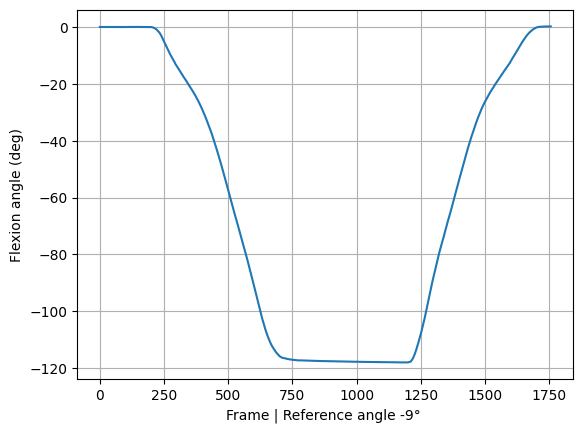

Minimum angle: -118°
Maximum angle:   0°
Angle range: 118°

Tibia RMS  (mm): 3.12
Femur RMS  (mm): 3.76
Patella RMS(mm): 2.28


In [8]:

# LOAD MESH → WORLD TRANSFORMS (MOTIVE WORLD)

R_tibia,   T_tibia   = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_tibia.npz")
R_femur,   T_femur   = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_femur.npz")
R_patella, T_patella = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_patella.npz")

# FLEXION ANGLE
angle = knee_flexion_angle(R_tibia, T_tibia, R_femur, T_femur, plot=True, anatomy=anatomy)
print(f"Minimum angle: {angle.min():.0f}°")
print(f"Maximum angle:   {angle.max():.0f}°")
print(f"Angle range: {angle.max() - angle.min():.0f}°\n")

# RMS ERROR
err_tibia, err_femur, err_patella = RMS_error(
    R_tibia, T_tibia,
    R_femur, T_femur,
    R_patella, T_patella,
    anatomy=anatomy,
    tibia_global_csv="../data/csv_files/tibiaGlobalPoints.csv",
    femur_global_csv="../data/csv_files/femurGlobalPoints.csv",
    patella_global_csv="../data/csv_files/patellaGlobalPoints.csv",
    
)

print(f"Tibia RMS  (mm): {err_tibia.mean() * 1000:.2f}")
print(f"Femur RMS  (mm): {err_femur.mean() * 1000:.2f}")
print(f"Patella RMS(mm): {err_patella.mean() * 1000:.2f}")
